# 03 — Arquitectura de Línea de Base
**Proyecto:** NLP Disaster Tweets Classification  
**Curso:** Fundamentos de Deep Learning — Universidad de Antioquia  
**Autor:** Assandry Barón Rodríguez  

Este notebook entrena el modelo de línea de base: un **Bidirectional LSTM**
con capa de Embedding entrenada desde cero. Carga los artefactos generados
por el Notebook 02 y produce el archivo `submission.csv`.

---
**Contenido**
1. Configuración del entorno y GPU
2. Carga de artefactos preprocesados
3. Hiperparámetros del modelo
4. Métrica F1 personalizada
5. Arquitectura Bidirectional LSTM
6. Entrenamiento con callbacks
7. Curvas de entrenamiento
8. Evaluación en validación
9. Predicciones y submission


## 1. Configuración del Entorno y GPU

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
import numpy  as np
import pandas as pd

warnings.filterwarnings('ignore')

BASE_PATH  = '/content/drive/MyDrive/NLP_Disaster_Tweets'
DATA_PATH  = os.path.join(BASE_PATH, 'data')
MODEL_PATH = os.path.join(BASE_PATH, 'models')

os.makedirs(MODEL_PATH, exist_ok=True)

print('Verificando artefactos del Notebook 02 ...')
required = ['X_train.npy','X_val.npy','y_train.npy','y_val.npy','X_test.npy']
for f in required:
    full   = os.path.join(DATA_PATH, f)
    status = '✅' if os.path.exists(full) else '❌  FALTA — ejecuta primero el Notebook 02'
    print(f'  {status}  {f}')


Mounted at /content/drive
Verificando artefactos del Notebook 02 ...
  ✅  X_train.npy
  ✅  X_val.npy
  ✅  y_train.npy
  ✅  y_val.npy
  ✅  X_test.npy


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models   import Sequential
from tensorflow.keras.layers   import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow : {tf.__version__}')
print(f'GPU activa : {bool(gpus)}  →  {gpus}')
if not gpus:
    print('  ⚠️  Sin GPU — ve a Entorno de ejecución → Cambiar tipo → GPU T4')


TensorFlow : 2.20.0
GPU activa : True  →  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Carga de Artefactos Preprocesados

In [3]:
import pickle

X_train = np.load(os.path.join(DATA_PATH, 'X_train.npy'))
X_val   = np.load(os.path.join(DATA_PATH, 'X_val.npy'))
y_train = np.load(os.path.join(DATA_PATH, 'y_train.npy'))
y_val   = np.load(os.path.join(DATA_PATH, 'y_val.npy'))
X_test  = np.load(os.path.join(DATA_PATH, 'X_test.npy'))

with open(os.path.join(MODEL_PATH, 'tokenizer.pkl'), 'rb') as f:
    tokenizer = pickle.load(f)

test_ids = pd.read_csv(os.path.join(DATA_PATH, 'test_ids.csv'))

print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}  (Desastre: {y_train.sum():.0f} | No: {(y_train==0).sum():.0f})')
print(f'y_val   : {y_val.shape}    (Desastre: {y_val.sum():.0f} | No: {(y_val==0).sum():.0f})')
print(f'Tokenizer vocab size: {len(tokenizer.word_index):,}')


X_train : (6471, 50)
X_val   : (1142, 50)
X_test  : (3263, 50)
y_train : (6471,)  (Desastre: 2780 | No: 3691)
y_val   : (1142,)    (Desastre: 491 | No: 651)
Tokenizer vocab size: 14,034


## 3. Hiperparámetros del Modelo

In [4]:
# ── Hiperparámetros centralizados ─────────────────────────────────────────────
# Modifica aquí para experimentar con distintas configuraciones.

VOCAB_SIZE    = 10_000   # Debe coincidir con el Notebook 02
MAX_LEN       = 50       # Debe coincidir con el Notebook 02
EMBEDDING_DIM = 128      # Dimensión del espacio de embedding
LSTM_UNITS    = 64       # Unidades LSTM por dirección
DROPOUT_RATE  = 0.40     # Dropout después del LSTM
DENSE_UNITS   = 32       # Neuronas en la capa densa oculta
BATCH_SIZE    = 64
EPOCHS        = 20
LR            = 1e-3     # Learning rate inicial Adam

print('Hiperparámetros:')
params = {
    'VOCAB_SIZE': VOCAB_SIZE, 'MAX_LEN': MAX_LEN,
    'EMBEDDING_DIM': EMBEDDING_DIM, 'LSTM_UNITS': LSTM_UNITS,
    'DROPOUT_RATE': DROPOUT_RATE, 'DENSE_UNITS': DENSE_UNITS,
    'BATCH_SIZE': BATCH_SIZE, 'EPOCHS': EPOCHS, 'LR': LR,
}
for k, v in params.items():
    print(f'  {k:<16} = {v}')


Hiperparámetros:
  VOCAB_SIZE       = 10000
  MAX_LEN          = 50
  EMBEDDING_DIM    = 128
  LSTM_UNITS       = 64
  DROPOUT_RATE     = 0.4
  DENSE_UNITS      = 32
  BATCH_SIZE       = 64
  EPOCHS           = 20
  LR               = 0.001


## 4. Métrica F1 Personalizada

In [5]:
class F1Score(tf.keras.metrics.Metric):
    """
    F1-Score como métrica nativa de Keras.
    Fórmula: F1 = 2 * Precision * Recall / (Precision + Recall)

    Se usa como objetivo del EarlyStopping (mode='max') para que el
    modelo guarde el checkpoint con mejor equilibrio entre precisión y recall,
    apropiado para el problema de clasificación de desastres donde los
    Falsos Negativos y Falsos Positivos tienen costos similares.
    """
    def __init__(self, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()
        self.recall    = tf.keras.metrics.Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return tf.math.divide_no_nan(2.0 * p * r, p + r)

    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()

print('✅ Clase F1Score definida')


✅ Clase F1Score definida


## 5. Arquitectura Bidirectional LSTM

### Diagrama de la arquitectura

```
Input (MAX_LEN=50 tokens enteros)
        │
        ▼
┌─────────────────────────────────────────────┐
│  Embedding  (10000 → 128 dims)              │  Aprende representaciones densas
└─────────────────────────────────────────────┘
        │
        ▼
┌─────────────────────────────────────────────┐
│  Bidirectional LSTM (64 unidades × 2 dirs)  │  Captura contexto ←→
│  dropout=0.3  |  recurrent_dropout=0.2      │
└─────────────────────────────────────────────┘
        │  (128 features: 64 forward + 64 backward)
        ▼
┌─────────────────────────────────────────────┐
│  Dropout (0.40)                             │  Regularización
└─────────────────────────────────────────────┘
        │
        ▼
┌─────────────────────────────────────────────┐
│  Dense (32, ReLU)                           │  Representación intermedia
└─────────────────────────────────────────────┘
        │
        ▼
┌─────────────────────────────────────────────┐
│  Dense (1, Sigmoid)                         │  Probabilidad ∈ [0,1]
└─────────────────────────────────────────────┘
        │
        ▼
 Clase 0 (< 0.5) | Clase 1 (≥ 0.5)
```

**Por qué Bidirectional:** Los tweets presentan dependencias de contexto bidireccionales.
Por ejemplo, en *"My heart was on fire"* la palabra *"fire"* en un contexto de clase 0 solo
se puede interpretar correctamente leyendo toda la oración en ambas direcciones.


In [6]:
def build_model() -> tf.keras.Model:
    """Construye y retorna el modelo Bidirectional LSTM."""
    model = Sequential([
        # Capa 1: Embedding — representación densa de palabras
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_LEN,
            name='embedding'
        ),
        # Capa 2: Bidirectional LSTM — dependencias temporales en ambas direcciones
        Bidirectional(LSTM(
            units=LSTM_UNITS,
            dropout=0.3,           # Dropout en entradas
            recurrent_dropout=0.2, # Dropout en estados recurrentes
            name='lstm'
        ), name='bidirectional'),
        # Capa 3: Dropout de regularización
        Dropout(DROPOUT_RATE, name='dropout'),
        # Capa 4: Dense con activación ReLU
        Dense(DENSE_UNITS, activation='relu', name='dense_hidden'),
        # Capa 5: Salida binaria con Sigmoid
        Dense(1, activation='sigmoid', name='output')
    ], name='BiLSTM_DisasterTweets')
    return model


model = build_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy',      # Pérdida para clasificación binaria
    metrics=['accuracy', F1Score()]
)

model.summary()
print()
trainable = sum(np.prod(w.shape) for w in model.trainable_weights)
print(f'Parámetros entrenables: {trainable:,}')


Model: "BiLSTM_DisasterTweets"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Parámetros entrenables: 0


## 6. Entrenamiento con Callbacks

In [7]:
callbacks = [
    # EarlyStopping: detiene si val_f1_score no mejora en 4 épocas
    # restore_best_weights=True → recupera automáticamente el mejor checkpoint
    EarlyStopping(
        monitor='val_f1_score',
        patience=4,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    # ReduceLROnPlateau: reduce LR a la mitad si val_loss se estanca
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print(f'Iniciando entrenamiento...')
print(f'  Épocas máximas : {EPOCHS}')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'  GPU activa     : {bool(tf.config.list_physical_devices("GPU"))}')
print()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)


Iniciando entrenamiento...
  Épocas máximas : 20
  Batch size     : 64
  GPU activa     : True

Epoch 1/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 364ms/step - accuracy: 0.6926 - f1_score: 0.5317 - loss: 0.5789 - val_accuracy: 0.8030 - val_f1_score: 0.7557 - val_loss: 0.4451 - learning_rate: 0.0010
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 33s 323ms/step - accuracy: 0.8465 - f1_score: 0.8075 - loss: 0.3609 - val_accuracy: 0.8091 - val_f1_score: 0.7651 - val_loss: 0.4568 - learning_rate: 0.0010
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.8979 - f1_score: 0.8752 - loss: 0.2701
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
102/102 ━━━━━━━━━━━━━━━━━━━━ 41s 323ms/step - accuracy: 0.8999 - f1_score: 0.8789 - loss: 0.2609 - val_accuracy: 0.7811 - val_f1_score: 0.7401 - val_loss: 0.5211 - learning_rate: 0.0010
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 34s 334ms/step - accuracy: 0.9346 - f1_score: 0.9217 - loss: 0.1810 - val_accuracy: 0.7723 - val_f1_s

## 7. Curvas de Entrenamiento

✅ Gráfica guardada: /content/drive/MyDrive/NLP_Disaster_Tweets/model_training_curves.png


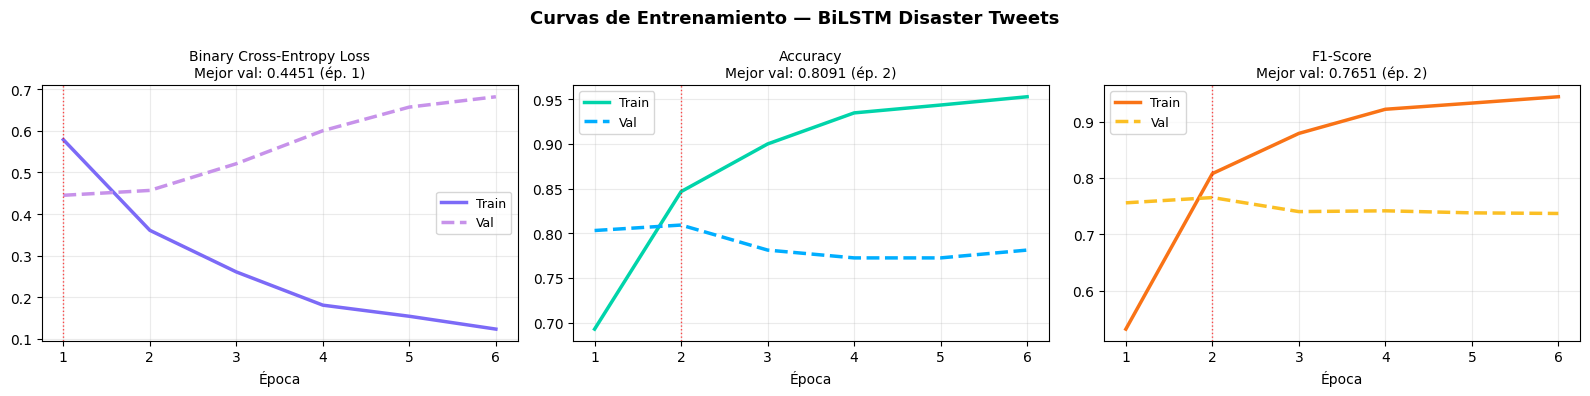

In [8]:
def plot_history(history, save_path=None):
    """Grafica las curvas de Loss, Accuracy y F1 por época."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle('Curvas de Entrenamiento — BiLSTM Disaster Tweets',
                 fontsize=13, fontweight='bold')

    cfg = [
        ('loss',     'val_loss',     'Binary Cross-Entropy Loss', '#7c6af7', '#c792ea'),
        ('accuracy', 'val_accuracy', 'Accuracy',                  '#00d4aa', '#00aeff'),
        ('f1_score', 'val_f1_score', 'F1-Score',                  '#f97316', '#fbbf24'),
    ]

    for ax, (tm, vm, title, c1, c2) in zip(axes, cfg):
        epochs_x = range(1, len(history.history[tm]) + 1)
        ax.plot(epochs_x, history.history[tm], color=c1, lw=2.5, label='Train')
        ax.plot(epochs_x, history.history[vm], color=c2, lw=2.5, label='Val', ls='--')

        # Marcar el mejor valor de validación
        if 'loss' in vm:
            best = min(history.history[vm])
            best_ep = history.history[vm].index(best) + 1
        else:
            best = max(history.history[vm])
            best_ep = history.history[vm].index(best) + 1

        ax.axvline(best_ep, color='red', ls=':', lw=1, alpha=0.7)
        ax.set_title(f'{title}\nMejor val: {best:.4f} (ép. {best_ep})', fontsize=10)
        ax.set_xlabel('Época')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.25)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'✅ Gráfica guardada: {save_path}')
    plt.show()

plot_history(history, save_path=os.path.join(BASE_PATH, 'model_training_curves.png'))


## 8. Evaluación en Validación

In [9]:
# Predicciones sobre validación
y_pred_proba = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0)
y_pred       = (y_pred_proba > 0.5).astype(int).flatten()

val_f1 = f1_score(y_val, y_pred)
print(f'F1-Score en validación : {val_f1:.4f}')
print()
print(classification_report(
    y_val, y_pred,
    target_names=['No Desastre (0)', 'Desastre Real (1)']
))


F1-Score en validación : 0.7651

                   precision    recall  f1-score   support

  No Desastre (0)       0.81      0.87      0.84       651
Desastre Real (1)       0.81      0.72      0.77       491

         accuracy                           0.81      1142
        macro avg       0.81      0.80      0.80      1142
     weighted avg       0.81      0.81      0.81      1142



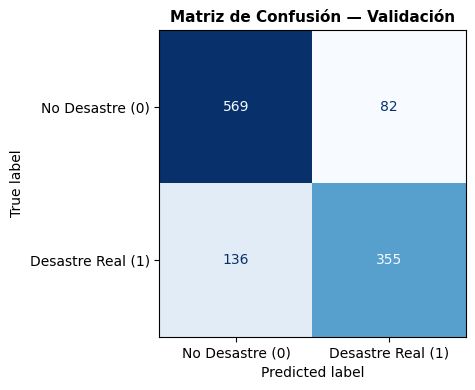

TP (Desastres correctos)     : 355
TN (No desastres correctos)  : 569
FP (Falsas alarmas)          : 82
FN (Desastres perdidos)      : 136

Precision manual : 0.8124
Recall manual    : 0.7230
F1 manual        : 0.7651


In [10]:
# Matriz de confusión
cm  = confusion_matrix(y_val, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No Desastre (0)', 'Desastre Real (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Validación', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'model_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TP (Desastres correctos)     : {tp}')
print(f'TN (No desastres correctos)  : {tn}')
print(f'FP (Falsas alarmas)          : {fp}')
print(f'FN (Desastres perdidos)      : {fn}')
print()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_manual = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
print(f'Precision manual : {precision:.4f}')
print(f'Recall manual    : {recall:.4f}')
print(f'F1 manual        : {f1_manual:.4f}')


## 9. Predicciones y Submission

In [11]:
# Guardar modelo
model_path = os.path.join(MODEL_PATH, 'bilstm_disaster_tweets.keras')
model.save(model_path)
print(f'✅ Modelo guardado: {model_path}')
print(f'   Tamaño: {os.path.getsize(model_path)/1024:.1f} KB')


✅ Modelo guardado: /content/drive/MyDrive/NLP_Disaster_Tweets/models/bilstm_disaster_tweets.keras
   Tamaño: 16251.7 KB


In [12]:
# Predicciones sobre test oficial de Kaggle
test_proba = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
test_preds = (test_proba > 0.5).astype(int).flatten()

submission = pd.DataFrame({
    'id'    : test_ids['id'],
    'target': test_preds
})

sub_path = os.path.join(BASE_PATH, 'submission.csv')
submission.to_csv(sub_path, index=False)

print(f'✅ submission.csv guardado: {sub_path}')
print(f'   Predicciones — Desastre: {test_preds.sum():,}  |  No desastre: {(test_preds==0).sum():,}')
print()
submission.head(10)


✅ submission.csv guardado: /content/drive/MyDrive/NLP_Disaster_Tweets/submission.csv
   Predicciones — Desastre: 1,212  |  No desastre: 2,051



,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1
5,12,1
6,21,0
7,22,0
8,27,0
9,29,0


In [13]:
# Descargar submission directamente
from google.colab import files
files.download(sub_path)
print('✅ Descarga iniciada — revisa tu carpeta Descargas')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descarga iniciada — revisa tu carpeta Descargas
